In [2]:
from matplotlib import font_manager, rcParams

font_manager.fontManager.addfont("/home/yfy/.local/share/fonts/Helvetica.ttf")
rcParams["font.family"] = ["Helvetica"]
rcParams["mathtext.fontset"] = "cm"

In [3]:
import os

import matplotlib.pyplot as plt


def draw_hyperparameter_sensitivity(
        dataset='filmtrust',
        hyperparameter='sh',
        x_labels=["0", "0.01", "0.02", "0.05", "0.1", "0.2", "0.5", "1.0"],
        hr10=[0.9185, 0.9161, 0.9177, 0.9152, 0.9152, 0.9161, 0.9152, 0.8892],
        ndcg10=[0.8252, 0.7761, 0.8175, 0.7922, 0.8005, 0.7925, 0.7782, 0.7989],
        x_label=r"$\rho_{\mathrm{ns}}$",
        y1_label='HR@10',
        y2_label='NDCG@10',
        y1_lim=(0.88, 0.92),
        y2_lim=(0.77, 0.83),
        line_width=4,
        marker_size=4,
        label_fontsize=14,
        label_fontfamily="Helvetica",
        tick_fontsize=12,
        tick_fontfamily="Helvetica",
        out_path='../exp_results/hyperparameter/'
):
    os.makedirs(out_path, exist_ok=True)

    fig_out = os.path.join(out_path, f"{dataset}_{hyperparameter}.pdf")
    legend_out = os.path.join(out_path, f"legend.pdf")

    x_idx = list(range(len(x_labels)))

    plt.rcParams["font.family"] = label_fontfamily

    fig, ax_left = plt.subplots(figsize=(5, 2), dpi=400)

    line1, = ax_left.plot(x_idx, hr10, marker="o", markersize=marker_size, linewidth=line_width, label=y1_label,
                          color='#F7A049')
    # ax_left.set_xlabel(x_label, fontsize=label_fontsize, fontfamily=label_fontfamily)
    ax_left.set_ylabel(y1_label, fontsize=tick_fontsize, fontfamily=label_fontfamily)

    ax_left.set_xticks(x_idx)
    ax_left.set_xticklabels(x_labels, fontfamily=tick_fontfamily, fontsize=tick_fontsize)

    ax_left.tick_params(axis="y", which="major", labelsize=tick_fontsize)
    for lbl in ax_left.get_yticklabels():
        lbl.set_fontfamily(tick_fontfamily)

    ax_left.set_xlim(-0.5, len(x_labels) - 0.5)

    if y1_lim is not None:
        ax_left.set_ylim(*y1_lim)

    ax_right = ax_left.twinx()
    line2, = ax_right.plot(x_idx, ndcg10, marker="s", markersize=marker_size, linestyle="--", linewidth=line_width,
                           label=y2_label, color='#154778')
    ax_right.set_ylabel(y2_label, fontsize=tick_fontsize, fontfamily=label_fontfamily)
    ax_right.tick_params(axis="y", which="major", labelsize=tick_fontsize)
    for lbl in ax_right.get_yticklabels():
        lbl.set_fontfamily(tick_fontfamily)
    if y2_lim is not None:
        ax_right.set_ylim(*y2_lim)

    ax_left.grid(True, axis="both", linestyle=":", linewidth=1, alpha=0.5)

    plt.tight_layout()
    plt.savefig(fig_out, bbox_inches="tight")
    print(f"Saved to: {fig_out}")

    legend_fig = plt.figure(figsize=(4, 0.5), dpi=400)  # 宽度/高度可按需调整
    legend = legend_fig.legend(
        handles=[line1, line2],
        labels=[y1_label, y2_label],
        loc="center",
        ncol=2,
        frameon=True,
        fontsize=12
    )

    ax = legend_fig.add_subplot(111)
    ax.axis('off')

    legend_fig.tight_layout()
    legend_fig.savefig(legend_out, bbox_inches="tight")
    print(f"Saved legend-only image to: {legend_out}")

In [52]:
dataset = 'lastfm_2k'
hyperparameter = 'ns'

Saved to: ../exp_results/hyperparameter/lastfm_2k_ns.pdf
Saved legend-only image to: ../exp_results/hyperparameter/legend.pdf


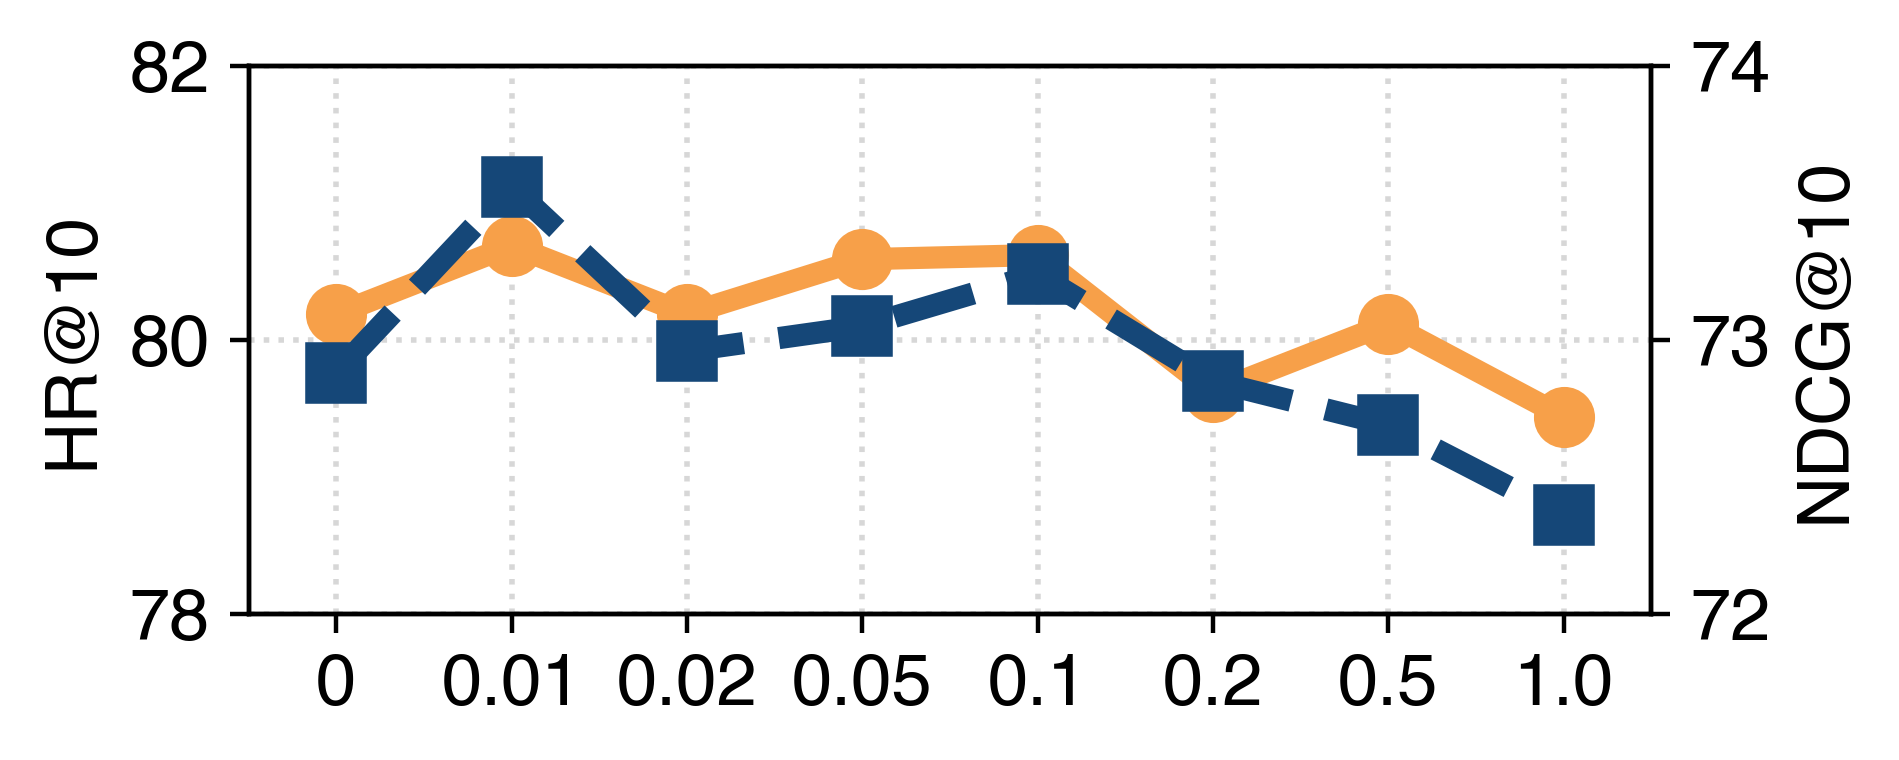

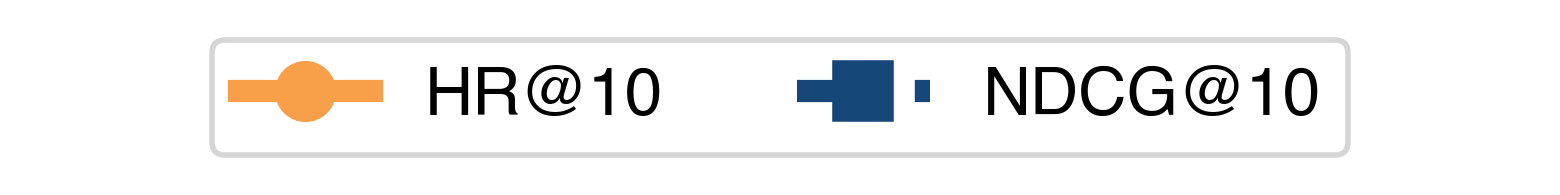

In [54]:
if hyperparameter == 'ns':
    x_label = r"$\rho_{\mathrm{ns}}$"
else:
    x_label = r"$\rho_{\mathrm{sh}}$"

if dataset == 'filmtrust' and hyperparameter == 'sh':
    hr10 = [0.9158, 0.9161, 0.9177, 0.9152, 0.9152, 0.9161, 0.9152, 0.8892]
    hr10 = [_ * 100 for _ in hr10]
    ndcg10 = [0.7872, 0.7761, 0.8175, 0.7922, 0.8005, 0.7925, 0.7782, 0.7989]
    ndcg10 = [_ * 100 for _ in ndcg10]
    hr_lim = (88, 92)
    ndcg_lim = (75, 85)
elif dataset == 'filmtrust' and hyperparameter == 'ns':
    hr10 = [0.9161, 0.9177, 0.9177, 0.9161, 0.9177, 0.9152, 0.9177, 0.9193]
    hr10 = [_ * 100 for _ in hr10]
    ndcg10 = [0.7729, 0.7732, 0.8175, 0.8030, 0.7904, 0.7797, 0.8150, 0.7945]
    ndcg10 = [_ * 100 for _ in ndcg10]
    hr_lim = (91, 93)
    ndcg_lim = (75, 85)
elif dataset == 'lastfm_2k' and hyperparameter == 'sh':
    hr10 = [63.50, 64.69, 64.69, 63.50, 64.50, 62.31, 62.00, 61.94]
    hr10 = [_ + 16 for _ in hr10]
    ndcg10 = [43.26, 44.56, 43.98, 43.69, 43.73, 43.11, 42.21, 42.30]
    ndcg10 = [_ + 29 for _ in ndcg10]
    hr_lim = (76, 82)
    ndcg_lim = (71, 74)
elif dataset == 'lastfm_2k' and hyperparameter == 'ns':
    hr10 = [80.19, 80.69, 80.19, 80.59, 80.62, 79.62, 80.12, 79.44]
    ndcg10 = [72.88, 73.56, 72.96, 73.05, 73.24, 72.85, 72.69,  72.36]
    hr_lim = (78, 82)
    ndcg_lim = (72, 74)
elif dataset == 'amazon_video' and hyperparameter == 'sh':
    hr10 = [62.75, 62.71, 62.64, 62.66, 62.60, 62.56, 61.77, 60.46]
    ndcg10 = [41.24, 41.26, 40.99, 41.22, 41.25, 41.38, 40.92, 40.66]
    hr_lim = (60, 63)
    ndcg_lim = (40, 42)
elif dataset == 'amazon_video' and hyperparameter == 'ns':
    hr10 = [62.64, 62.71, 62.61, 62.95, 62.96, 62.80, 62.61, 62.71]
    ndcg10 = [41.14, 41.26, 41.40, 41.40, 41.40, 41.44, 41.30, 41.15]
    hr_lim = (61, 64)
    ndcg_lim = (40, 43)
elif dataset == 'qb_article' and hyperparameter == 'sh':
    hr10 = [89.82, 89.87, 89.96, 89.93, 89.70, 89.78, 89.86, 89.59]
    ndcg10 = [62.29, 62.58, 62.65, 62.76, 62.36, 62.13, 61.32, 60.09]
    hr_lim = (89, 91)
    ndcg_lim = (60, 63)
elif dataset == 'qb_article' and hyperparameter == 'ns':
    hr10 = [89.68, 89.92, 89.85, 89.93, 89.86, 89.73, 89.80, 89.91]
    # ndcg10 = [62.03, 62.53, 62.47, 62.76, 62.77, 61.69, 62.24, 62.62]
    ndcg10 = [62.03, 62.53, 62.47, 62.76, 62.77, 62.09, 62.24, 62.22]
    hr_lim = (89, 91)
    ndcg_lim = (61, 63)
else:
    raise ValueError(f'unkown dataset: {dataset}')

draw_hyperparameter_sensitivity(
    dataset=dataset,
    hyperparameter=hyperparameter,
    x_labels=["0", "0.01", "0.02", "0.05", "0.1", "0.2", "0.5", "1.0"],
    hr10=hr10,
    ndcg10=ndcg10,
    x_label=x_label,
    y1_label='HR@10',
    y2_label='NDCG@10',
    y1_lim=hr_lim,
    y2_lim=ndcg_lim,
    line_width=4,
    marker_size=10,
    label_fontsize=13,
    label_fontfamily="Helvetica",
    tick_fontsize=13,
    tick_fontfamily="Helvetica",
    out_path='../exp_results/hyperparameter/'
)